In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import MobileNetV2
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Step 2 - Set Dataset Path
dataset_path = "/content/drive/MyDrive/dataset"

In [ ]:
dataset_path = "/content/drive/MyDrive/dataset"
for root, dirs, files in os.walk(dataset_path):
    print(f"{root}: {len(files)} files")

/content/drive/MyDrive/dataset: 0 files
/content/drive/MyDrive/dataset/One arm crossed: 300 files
/content/drive/MyDrive/dataset/Arms Crossed High (Chest): 305 files
/content/drive/MyDrive/dataset/Arms Crossed Low (Waist): 304 files
/content/drive/MyDrive/dataset/Arms Open and Neutral: 304 files
/content/drive/MyDrive/dataset/Hands in Pockets: 304 files


In [ ]:
def train_cnn(dataset_path):
    train_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="training",
        seed=42,
        image_size=(128, 128),
        batch_size=16
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="validation",
        seed=42,
        image_size=(128, 128),
        batch_size=16
    )
    class_names = train_ds.class_names
    return train_ds, val_ds, class_names

train_ds, val_ds, class_names = train_cnn(dataset_path)

Found 1517 files belonging to 5 classes.
Using 1214 files for training.
Found 1517 files belonging to 5 classes.
Using 303 files for validation.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
])

In [ ]:
model = models.Sequential([

    layers.Input(shape=(128, 128, 3)),
    data_augmentation,
    layers.Rescaling(1./255),

    layers.Conv2D(32, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(256, 3, activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Dropout(0.3),

    layers.Flatten(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(len(class_names), activation='softmax')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("cnn_model.keras", save_best_only=True, monitor='val_accuracy')
]

history = model.fit(train_ds, epochs=25, validation_data=val_ds, callbacks=callbacks, verbose=1)


Epoch 1/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.4629 - loss: 3.3987 - val_accuracy: 0.2046 - val_loss: 13.4286
Epoch 2/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.6425 - loss: 1.1123 - val_accuracy: 0.2706 - val_loss: 16.8979
Epoch 3/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.6837 - loss: 0.9701 - val_accuracy: 0.3003 - val_loss: 14.9024
Epoch 4/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.7043 - loss: 0.9133 - val_accuracy: 0.3993 - val_loss: 3.1104
Epoch 5/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 90s 1s/step - accuracy: 0.7850 - loss: 0.6675 - val_accuracy: 0.5545 - val_loss: 1.9854
Epoch 6/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 91s 1s/step - accuracy: 0.7883 - loss: 0.6156 - val_accuracy: 0.6568 - val_loss: 1.5812
Epoch 7/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.7982 - loss: 0.6372 - val_accuracy: 0.7030 - val_loss: 1.1666
Epoch 8/25
76/76 ━━━━━━━━━━━━━━━━━━━━ 89s 1s/step - accuracy: 0.7842 - loss: 0.6851 - val_accuracy: 0.8350 - val_l

In [ ]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy * 100:.2f}%")
print(f"Training Accuracy: {history.history['accuracy'][-1] * 100:.2f}%")

19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 204ms/step - accuracy: 0.8713 - loss: 0.3736
Validation Loss: 0.3736
Validation Accuracy: 87.13%
Training Accuracy: 87.31%


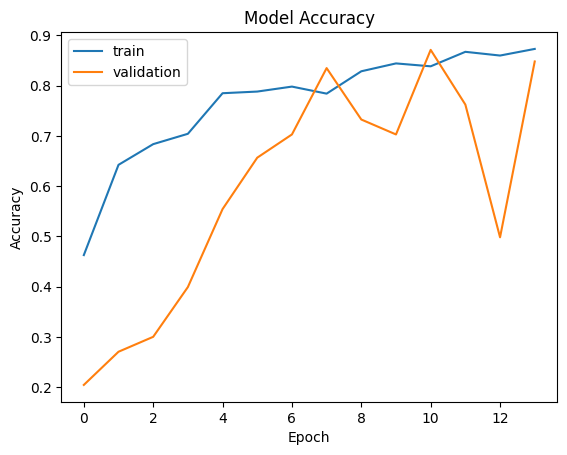

In [ ]:
plt.plot(history.history['accuracy'], label='train')
plt.plot(history.history['val_accuracy'], label='validation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.legend()

plt.show()

## **MOBILEV2 NET**



In [ ]:
def train_mobilenet(dataset_path):
    train_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="training",
        seed=42,
        image_size=(224, 224),
        batch_size=32
    )
    val_ds = tf.keras.utils.image_dataset_from_directory(
        dataset_path,
        validation_split=0.2,
        subset="validation",
        seed=42,
        image_size=(224, 224),
        batch_size=32
    )
    class_names = train_ds.class_names
    return train_ds, val_ds, class_names

train_ds, val_ds, class_names = train_mobilenet(dataset_path)

Found 1517 files belonging to 5 classes.
Using 1214 files for training.
Found 1517 files belonging to 5 classes.
Using 303 files for validation.


In [ ]:
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(AUTOTUNE)
val_ds = val_ds.cache().prefetch(AUTOTUNE)

data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.15),
    layers.RandomZoom(0.15),
    layers.RandomContrast(0.2),
    layers.RandomBrightness(0.1),
])

In [ ]:
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')
base_model.trainable = False

model = models.Sequential([
    layers.Input(shape=(224, 224, 3)),
    data_augmentation,
    tf.keras.layers.Rescaling(1./255),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(len(class_names), activation='softmax')
])

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

callbacks = [
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True),
    tf.keras.callbacks.ModelCheckpoint("mobilenet_model.keras", save_best_only=True, monitor='val_accuracy')
]

history_mobilenet = model.fit(train_ds, epochs=25, validation_data=val_ds, callbacks=callbacks, verbose=1)

Epoch 1/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 88s 2s/step - accuracy: 0.6549 - loss: 0.8685 - val_accuracy: 0.8614 - val_loss: 0.3962
Epoch 2/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.8311 - loss: 0.4565 - val_accuracy: 0.9241 - val_loss: 0.2736
Epoch 3/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 81s 2s/step - accuracy: 0.8600 - loss: 0.3539 - val_accuracy: 0.8746 - val_loss: 0.3546
Epoch 4/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.8839 - loss: 0.3129 - val_accuracy: 0.9571 - val_loss: 0.1826
Epoch 5/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 79s 2s/step - accuracy: 0.9217 - loss: 0.2322 - val_accuracy: 0.9604 - val_loss: 0.1555
Epoch 6/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.9325 - loss: 0.2066 - val_accuracy: 0.9670 - val_loss: 0.1565
Epoch 7/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.9217 - loss: 0.2250 - val_accuracy: 0.9439 - val_loss: 0.1807
Epoch 8/25
38/38 ━━━━━━━━━━━━━━━━━━━━ 78s 2s/step - accuracy: 0.9283 - loss: 0.2063 - val_accuracy: 0.9571 - val_loss:

In [ ]:
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy * 100:.2f}%")
print(f"Training Accuracy: {history_mobilenet.history['accuracy'][-1] * 100:.2f}%")

10/10 ━━━━━━━━━━━━━━━━━━━━ 13s 1s/step - accuracy: 0.9670 - loss: 0.1077
Validation Loss: 0.1077
Validation Accuracy: 96.70%
Training Accuracy: 95.30%


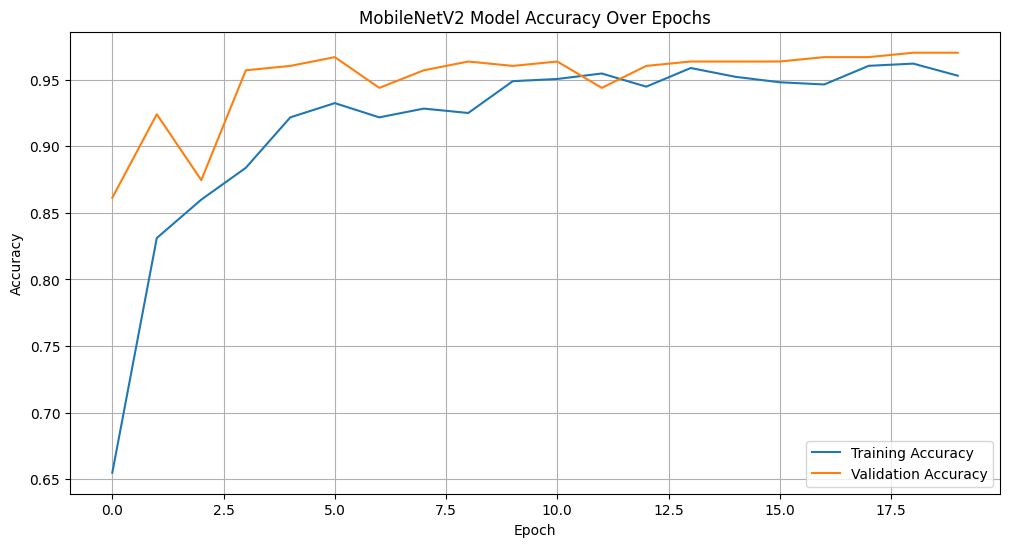

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(history_mobilenet.history['accuracy'], label='Training Accuracy')
plt.plot(history_mobilenet.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('MobileNetV2 Model Accuracy Over Epochs')
plt.legend()
plt.grid(True)
plt.show()

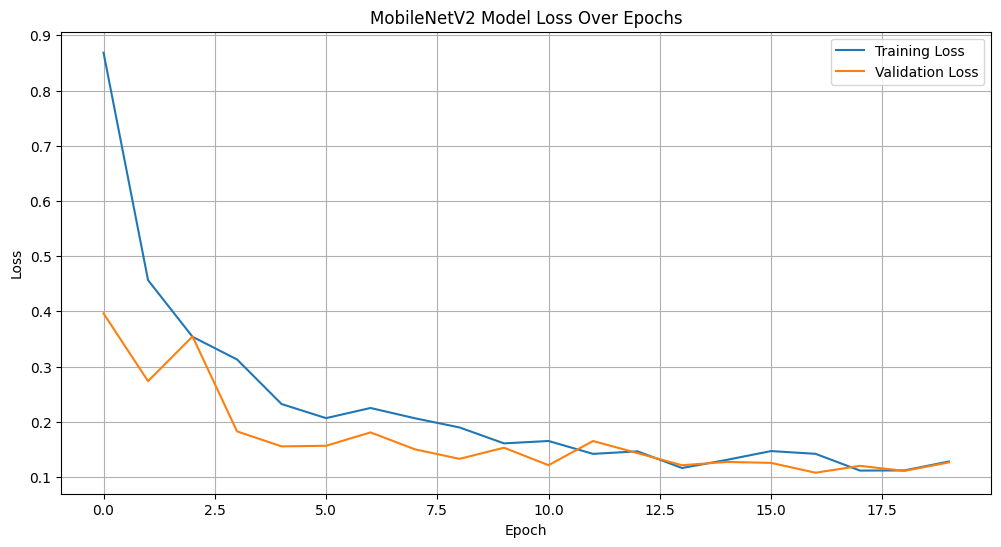

In [ ]:
plt.figure(figsize=(12, 6))
plt.plot(history_mobilenet.history['loss'], label='Training Loss')
plt.plot(history_mobilenet.history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MobileNetV2 Model Loss Over Epochs')
plt.legend()
plt.grid(True)
plt.show()